In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np
import parse_airfoil

filename = "airfoil_data/xf-naca2412-il-1000000.csv"
# filename = "airfoil_data/xf-n0012-il-1000000.csv"

alphas, cl, cd = parse_airfoil.parse_airfoil(filename)
alpha_min, alpha_max, alpha_step = parse_airfoil.clean_up_airfoil(alphas, cl, cd)

print(f"{alpha_min=} {alpha_max=} {alpha_step=}")

alpha_min=-17.5 alpha_max=19.25 alpha_step=0.25


[53] Warning: alpha values are not evenly spaced: 0.5 != 0.25. Will auto-interpolate.
[78] Warning: alpha values are not evenly spaced: 0.75 != 0.25. Will auto-interpolate.


In [17]:
def lerp(factor: float, a: float, b: float) -> float:
    return (1 - factor) * a + factor * b


def sign_locked_extrapolate(penultimate: float, ultimate: float, excess_alpha: float) -> float:
    slope = (ultimate - penultimate) / alpha_step
    extrapolated = ultimate + slope * abs(excess_alpha)

    if ultimate < 0:
        return min(extrapolated, 0)
    else:
        return max(0, extrapolated)


def get_value(alpha: float, values: list[float]) -> float:
    if alpha < alpha_min:
        excess = alpha_min - alpha
        return sign_locked_extrapolate(values[1], values[0], excess)
    elif alpha > alpha_max:
        excess = alpha - alpha_max
        return sign_locked_extrapolate(values[-2], values[-1], excess)
    else:
        lower_index = int((alpha - alpha_min) / alpha_step)
        upper_index = lower_index + 1

        factor = (alpha - (alpha_min + lower_index * alpha_step)) / alpha_step
        if upper_index >= len(values):
            return values[lower_index]
        else:
            return lerp(factor, values[lower_index], values[upper_index])


C_P = 1.9  # flat plate pressure coefficient


def flat_plate_cl(alpha: float) -> float:
    return C_P / 2 * math.sin(math.radians(2*alpha))


def flat_plate_cd(alpha: float) -> float:
    sin_alpha = math.sin(math.radians(alpha))
    return C_P * sin_alpha * sin_alpha


def get_cl_foil(alpha: float) -> float:
    return get_value(alpha, cl)


def get_cd_foil(alpha: float) -> float:
    return get_value(alpha, cd)


EXTRAPOLATION_DIST = 6.5
BLEND_LENGTH = 35


def blend_to_flat(alpha: float, c_foil: float, c_flat: float) -> float:
    if alpha < 0:
        blend_start = abs(alpha_min - EXTRAPOLATION_DIST)
    else:
        blend_start = abs(alpha_max + EXTRAPOLATION_DIST)

    blend_end = blend_start + BLEND_LENGTH

    if abs(alpha) <= blend_start:
        return c_foil
    elif abs(alpha) >= blend_end:
        return c_flat
    else:
        factor = (abs(alpha) - blend_start) / BLEND_LENGTH
        factor = factor * factor * (3 - 2 * factor)
        return lerp(factor, c_foil, c_flat)


def clamp(v: float, min_: float, max_: float) -> float:
    return max(min_, min(v, max_))


def get_cl(alpha: float) -> float:
    return blend_to_flat(alpha, get_cl_foil(alpha), flat_plate_cl(alpha))


def get_cd(alpha: float) -> float:
    return blend_to_flat(alpha, get_cd_foil(alpha), flat_plate_cd(alpha))


def get_blend_factor(alpha: float) -> float:
    return blend_to_flat(alpha, 0, 1)

0

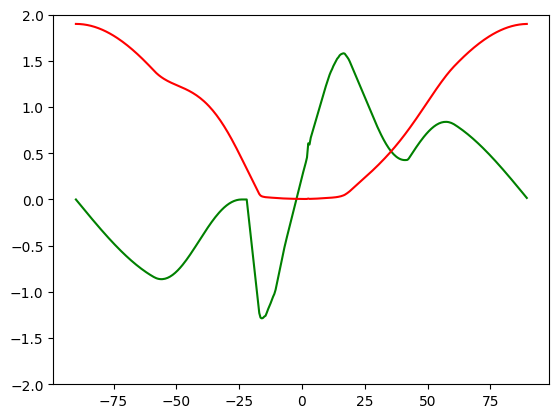

In [18]:
plot_alphas = np.arange(-90, 90, 0.5)
plot_cl = list(map(get_cl, plot_alphas))
plot_cd = list(map(get_cd, plot_alphas))
plot_blend = list(map(get_blend_factor, plot_alphas))

plot = plt.subplot()
ax = plt.gca()

ax.set_ylim(-2.0, 2.0)

plot.plot(plot_alphas, plot_cl, color="green")
plot.plot(plot_alphas, plot_cd, color="red")
# plot.plot(plot_alphas, plot_blend, color="blue")
0

0

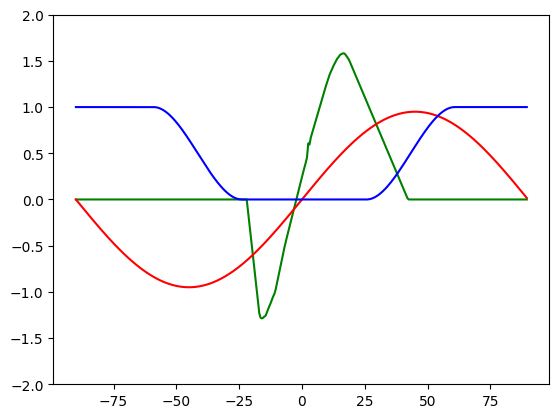

In [19]:
plot_alphas = np.arange(-90, 90, 0.5)
plot_cl_foil = list(map(get_cl_foil, plot_alphas))
plot_cl_flat = list(map(flat_plate_cl, plot_alphas))
plot_blend = list(map(get_blend_factor, plot_alphas))

plot = plt.subplot()
ax = plt.gca()

ax.set_ylim(-2.0, 2.0)

plot.plot(plot_alphas, plot_cl_foil, color="green")
plot.plot(plot_alphas, plot_cl_flat, color="red")
plot.plot(plot_alphas, plot_blend, color="blue")
0